Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-17-23_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 204799  =      0.000 ...   199.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


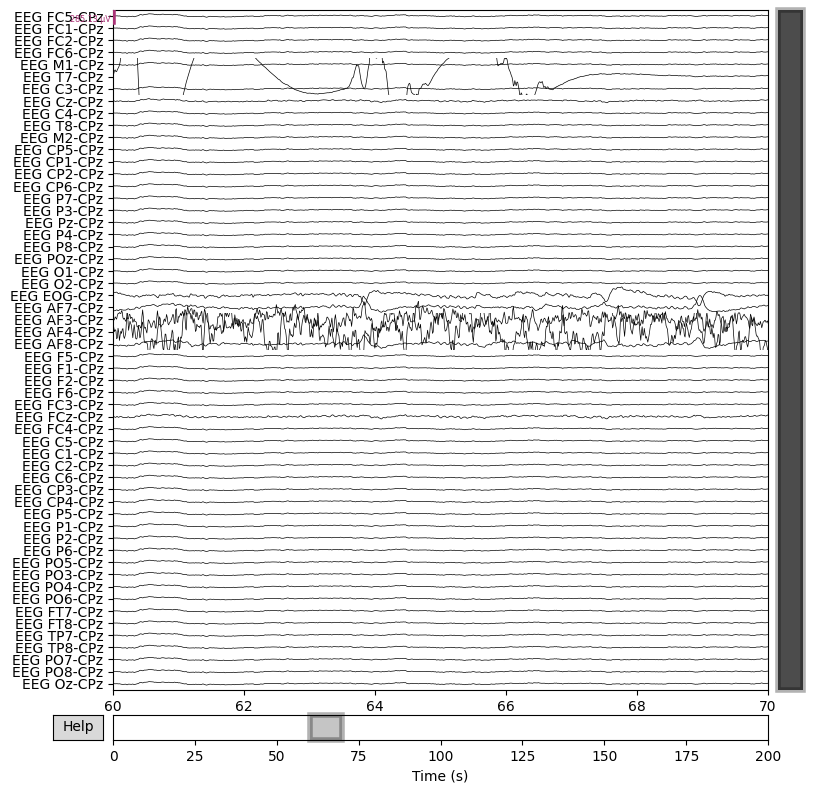

In [2]:
import mne

def plot_all_channels(file_path, start_time=60):
    
    # Load EDF file
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    # Keep only EEG channels
    raw.pick_types(eeg=True)
    
    # Filtering (same as your pipeline)
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    
    # Referencing
    raw.set_eeg_reference('average')
    
    # Remove annotations (clean view)
    raw.set_annotations(None)
    
    # Plot ALL channels
    raw.plot(
        start=start_time,      # start time in seconds
        duration=10,           # 10-second window
        n_channels=len(raw.ch_names),  # ✅ shows ALL channels
        scalings='auto',
        title="EEG - All Channels (Scrollable View)"
    )


plot_all_channels(
    r"E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-17-23_Segment_0.edf",
    start_time=60
)

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-01-25_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 111499  =      0.000 ...   222.998 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 16501 samples (33.002 s)

Filtering raw data in 1 contiguous segment


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


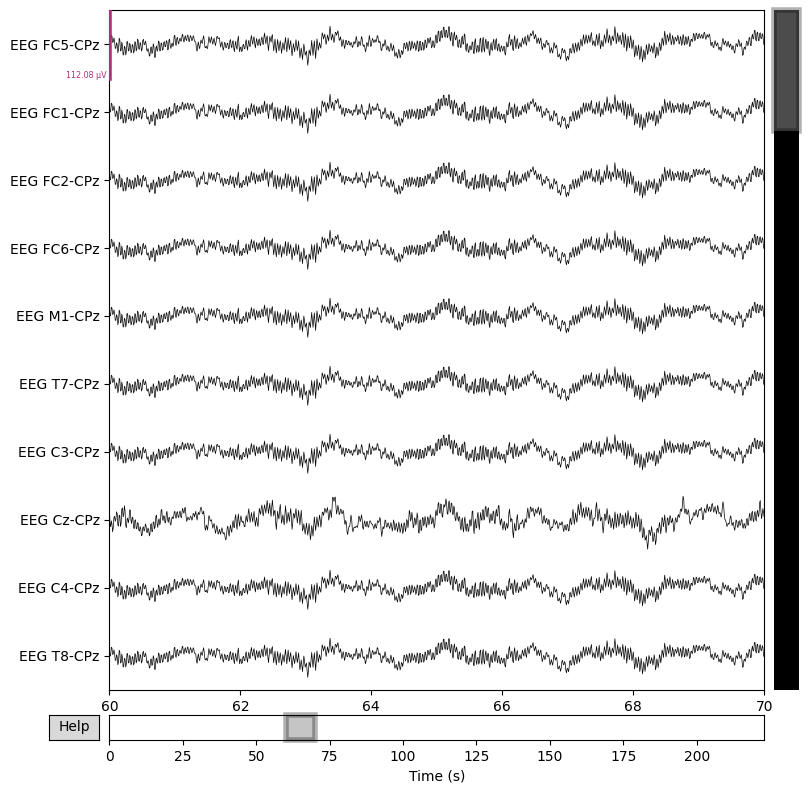

In [ ]:
import mne

def plot_continuous_window(file_path, start_time=60):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    
    raw.pick_types(eeg=True)
    
    # Filtering
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    
    # Referencing
    raw.set_eeg_reference('average')
    
  
    raw.set_annotations(None)
    
    
    raw.plot(
        start=start_time,   
        duration=10,        
        n_channels=10,
        scalings='auto',
        title="Continuous EEG (Scrollable Window)"
    )


plot_continuous_window(r"E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-01-25_Segment_0.edf", start_time=60)

In [ ]:
import os
import mne
import numpy as np
import pandas as pd
from scipy.signal import welch

def bandpower(freqs, psd, low, high):
    idx = np.logical_and(freqs >= low, freqs <= high)
    return np.trapz(psd[idx], freqs[idx])


def extract_features(file_path, label):

    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    # Keep EEG only
    raw.pick_types(eeg=True)

    # Filtering 
    raw.filter(0.5, 45, verbose=False)
    raw.notch_filter(50, verbose=False)

    # Average reference
    raw.set_eeg_reference('average', verbose=False)

    
    data, fs = raw.get_data(return_times=False), raw.info['sfreq']

    band_features = []

    # EEG bands
    bands = {
        "Delta": (0.5, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta":  (13, 30),
        "Gamma": (30, 45)
    }

    all_band_values = {key: [] for key in bands}

    for channel in data:
        freqs, psd = welch(channel, fs=fs, nperseg=1024)

        total_power = np.trapz(psd, freqs)

        for band, (low, high) in bands.items():
            bp = bandpower(freqs, psd, low, high)
            all_band_values[band].append(bp / total_power)  # RELATIVE POWER

    # Average across channels
    features = {band: np.mean(values) for band, values in all_band_values.items()}
    features["Label"] = label

    return features


def process_folder(folder_path, label):

    dataset = []

    for file in os.listdir(folder_path):
        if file.endswith(".edf"):
            file_path = os.path.join(folder_path, file)
            print("Processing:", file)
            features = extract_features(file_path, label)
            dataset.append(features)

    return dataset


tbi_folder = r"E:\aditi_eeg\visual_eeg\tbi"
non_tbi_folder = r"E:\aditi_eeg\visual_eeg\non_tbi"

tbi_data = process_folder(tbi_folder, label=1)
non_tbi_data = process_folder(non_tbi_folder, label=0)


df = pd.DataFrame(tbi_data + non_tbi_data)

# Save CSV
df.to_csv("eeg_bandpower_dataset.csv", index=False)

print("\n Dataset created successfully!")
print(df.head())

Processing: p1_a_2026-04-06_11-01-25_Segment_0.edf
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Processing: p1_a_2026-04-06_11-17-23_Segment_0.edf
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Processing: p1_a_2026-04-06_11-24-25_Segment_0.edf
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Processing: p1_a_2026-04-06_11-41-22_Segment_0.edf
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Processing: p4_visual_2026-04-06_12-31-59_Segment_0.edf
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Processing: p5_visual_2026-04-06_12-39-57_Segment_0.edf
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Processing: p6_visual_2026-04-06_12-52-05_Segment_0.edf
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Processing: p7_visual_2026-04-06_12-59-46_Segment_0.edf
NOTE: pick_types() is a legacy fu

Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p4_visual_2026-04-06_12-31-59_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 221183  =      0.000 ...   215.999 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)

EEG channel type selected for re-referencing


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


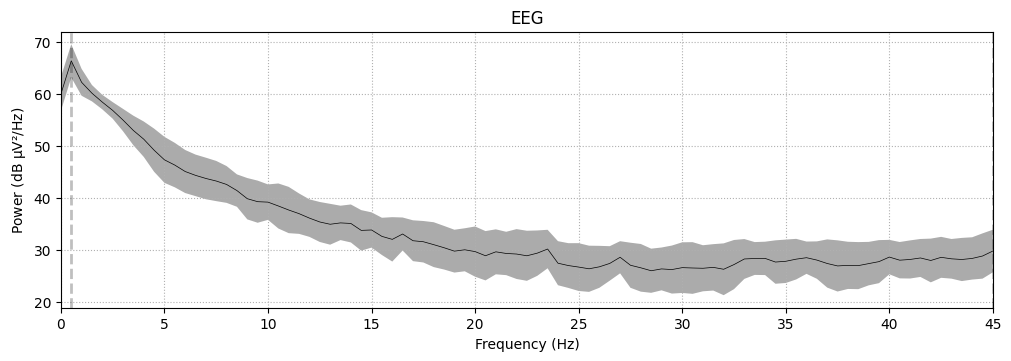

In [13]:
import mne
import matplotlib.pyplot as plt

def plot_psd(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)

    raw.pick_types(eeg=True)
    raw.filter(0.5, 45)
    raw.notch_filter(50)
    raw.set_eeg_reference('average')

    raw.plot_psd(fmax=45, average=True)
    plt.show()

# Example
plot_psd(r"E:\aditi_eeg\visual_eeg\tbi\p4_visual_2026-04-06_12-31-59_Segment_0.edf")

In [ ]:
def clean_channel_names(raw):
    new_names = {}

    for ch in raw.ch_names:
        clean = ch.replace("EEG ", "")   
        clean = clean.replace("-CPz", "") 
        new_names[ch] = clean

    raw.rename_channels(new_names)
    return raw

In [25]:
import mne
import numpy as np
from mne.time_frequency import psd_array_welch


def clean_names(raw):
    return raw.rename_channels(
        {ch: ch.replace("EEG ", "").replace("-CPz", "") for ch in raw.ch_names}
    )


def extract_p300_psd_features(file_path):

    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    raw.pick_types(eeg=True)

    raw = clean_names(raw)

    raw.filter(0.5, 45, verbose=False)
    raw.notch_filter(50, verbose=False)
    raw.set_eeg_reference('average', verbose=False)

    data = raw.get_data()
    sfreq = raw.info['sfreq']

    psd, freqs = psd_array_welch(
        data,
        sfreq=sfreq,
        fmin=0.5,
        fmax=45,
        n_fft=1024
    )

    bands = {
        "Delta": (0.5, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta":  (13, 30)
    }

    features = {}

    for band, (fmin, fmax) in bands.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        band_power = np.mean(psd[:, idx], axis=1)   # per channel

        features[f"{band}_mean"] = np.mean(band_power)
        features[f"{band}_std"] = np.std(band_power)

    return features


# RUN
file_path = r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"
print(extract_p300_psd_features(file_path))

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)
{'Delta_mean': 2.4949809493567645e-07, 'Delta_std': 2.92588084881776e-07, 'Theta_mean': 6.0298783928276254e-09, 'Theta_std': 2.4638007548036766e-08, 'Alpha_mean': 1.2449769549787104e-09, 'Alpha_std': 4.971643942531115e-09, 'Beta_mean': 1.9507965012177193e-10, 'Beta_std': 7.179425194624233e-10}


In [ ]:
import mne
import numpy as np
from mne.preprocessing import ICA
from mne.time_frequency import psd_array_welch


def clean_names(raw):
    return raw.rename_channels(
        {ch: ch.replace("EEG ", "").replace("-CPz", "") for ch in raw.ch_names}
    )


def clean_eeg_and_psd(file_path):

    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    raw.pick_types(eeg=True)

    raw = clean_names(raw)

 
    raw.filter(1.0, 40, verbose=False)
    raw.notch_filter(50, verbose=False)
    raw.set_eeg_reference('average', verbose=False)

   
    ica = ICA(n_components=15, random_state=97, max_iter="auto")
    ica.fit(raw)


    raw_clean = ica.apply(raw.copy())

  
    data = raw_clean.get_data()
    sfreq = raw_clean.info['sfreq']

    psd, freqs = psd_array_welch(
        data,
        sfreq=sfreq,
        fmin=1,
        fmax=40,
        n_fft=2048
    )

 
    bands = {
        "Delta": (1, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta":  (13, 30)
    }

    features = {}

    total_power = np.sum(psd, axis=1)

    for band, (fmin, fmax) in bands.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        band_power = np.sum(psd[:, idx], axis=1)

        rel_power = band_power / total_power

        features[f"{band}_mean"] = np.mean(rel_power)
        features[f"{band}_std"] = np.std(rel_power)

    return features



file_path = r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"

features = clean_eeg_and_psd(file_path)

print("\n=== FINAL CLEAN ICA + PSD FEATURES ===")
print(features)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Fitting ICA to data using 56 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 3.9s.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 56 PCA components


C:\Users\HP\AppData\Local\Temp\ipykernel_48576\677409774.py:37: RuntimeWarning: Using n_components=15 (resulting in n_components_=15) may lead to an unstable mixing matrix estimation because the ratio between the largest (52) and smallest (4.9e-31) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 10
  ica.fit(raw)


Effective window size : 2.000 (s)

=== FINAL CLEAN ICA + PSD FEATURES ===
{'Delta_mean': 0.6838321416481722, 'Delta_std': 0.08955679360409592, 'Theta_mean': 0.16651662050634114, 'Theta_std': 0.030502156711616754, 'Alpha_mean': 0.15249972835567352, 'Alpha_std': 0.05597436382122405, 'Beta_mean': 0.049691256614116885, 'Beta_std': 0.01684652767835762}


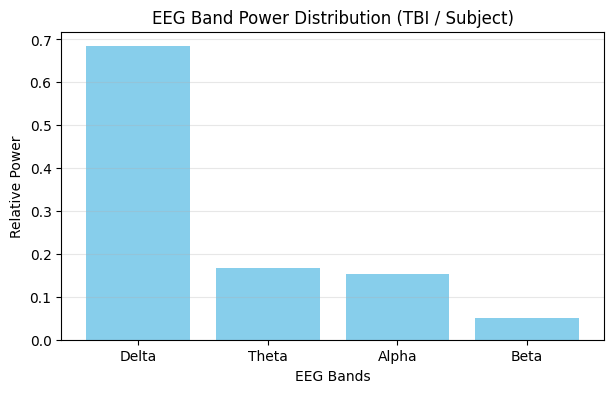

In [33]:
import matplotlib.pyplot as plt

def plot_band_features(features):

    bands = ["Delta", "Theta", "Alpha", "Beta"]

    values = [
        features["Delta_mean"],
        features["Theta_mean"],
        features["Alpha_mean"],
        features["Beta_mean"]
    ]

    plt.figure(figsize=(7,4))
    plt.bar(bands, values, color="skyblue")

    plt.title("EEG Band Power Distribution (TBI / Subject)")
    plt.ylabel("Relative Power")
    plt.xlabel("EEG Bands")

    plt.grid(axis="y", alpha=0.3)
    plt.show()
plot_band_features(features)

In [36]:
import mne
import numpy as np


def simple_topomap(raw, psd, freqs):

    print("Function started")

    # MUST set montage
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')

    print("Montage set")

    bands = {
        "Delta": (1, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta":  (13, 30)
    }

    print("PSD shape:", psd.shape)
    print("Channels:", len(raw.ch_names))

    for name, (fmin, fmax) in bands.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        band_power = np.mean(psd[:, idx], axis=1)

        print("Plotting:", name)

        mne.viz.plot_topomap(
            band_power,
            raw.info,
            cmap="coolwarm",
            contours=0,
            show=True
        )

    print("Done")

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt


def topomap(raw, psd, freqs):

    
    raw.rename_channels({ch: ch.replace("EEG ", "").replace("-CPz", "") for ch in raw.ch_names})

    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')

 
    bands = {
        "Delta (Slow)": (1, 4),
        "Theta (Cognitive)": (4, 8),
        "Alpha (Relaxed)": (8, 13),
        "Beta (Attention)": (13, 30)
    }

    # Create ONE combined brain activity map 
    brain_map = np.zeros(len(raw.ch_names))

    for name, (fmin, fmax) in bands.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        band_power = np.mean(psd[:, idx], axis=1)

        # weight contribution
        if "Delta" in name:
            brain_map += 0.4 * band_power
        elif "Theta" in name:
            brain_map += 0.3 * band_power
        elif "Alpha" in name:
            brain_map += 0.2 * band_power
        else:
            brain_map += 0.1 * band_power


    fig, ax = plt.subplots(figsize=(8, 6))

    im, _ = mne.viz.plot_topomap(
        brain_map,
        raw.info,
        cmap="RdBu_r",
        contours=6,
        show=False,
        axes=ax
    )

    plt.title("EEG Brain Activity Topography (PSD-based)", fontsize=14, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Power (Amplitude)", rotation=270, labelpad=15)

    #
    ax.text(0, 0.9, "Frontal", ha="center", fontsize=10, color="black")
    ax.text(-0.9, 0, "Left Temporal", fontsize=10, rotation=90)
    ax.text(0.9, 0, "Right Temporal", fontsize=10, rotation=270)
    ax.text(0, -0.9, "Occipital", ha="center", fontsize=10)

    plt.show()


    print("\n=== EEG SUMMARY ===")
    print("Mean Brain Activity:", np.mean(brain_map))
    print("Max Activity:", np.max(brain_map))
    print("Min Activity:", np.min(brain_map))

    print("\nNOTE:")
    print("Latency cannot be extracted from PSD.")
    print("Use ERP (P300 time-locked data) for latency analysis.")

In [49]:
topomap(raw, psd, freqs)

NameError: name 'topomap' is not defined

In [38]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import psd_array_welch

In [39]:
file_path = r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"

raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

raw.pick_types(eeg=True)

print(raw)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<RawEDF | p7_visual_2026-04-06_12-59-46_Segment_0.edf, 56 x 228352 (223.0 s), ~97.6 MB, data loaded>


In [40]:
raw.filter(1, 40, verbose=False)
raw.notch_filter(50, verbose=False)

raw.set_eeg_reference('average', verbose=False)

<RawEDF | p7_visual_2026-04-06_12-59-46_Segment_0.edf, 56 x 228352 (223.0 s), ~97.6 MB, data loaded>

In [41]:
montage = mne.channels.make_standard_montage('standard_1020')

raw.set_montage(montage, on_missing='ignore')

<RawEDF | p7_visual_2026-04-06_12-59-46_Segment_0.edf, 56 x 228352 (223.0 s), ~97.6 MB, data loaded>

In [42]:
data = raw.get_data()
sfreq = raw.info['sfreq']

psd, freqs = psd_array_welch(
    data,
    sfreq=sfreq,
    fmin=1,
    fmax=40,
    n_fft=2048
)

print("PSD shape:", psd.shape)

Effective window size : 2.000 (s)
PSD shape: (56, 79)


In [45]:
import mne
import numpy as np
import matplotlib.pyplot as plt


def plot_topomaps(raw, psd, freqs):

    # CLEAN NAMES
    raw.rename_channels({ch: ch.replace("EEG ", "").replace("-CPz", "") for ch in raw.ch_names})

    # FORCE MONTAGE (IMPORTANT FIX)
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, match_case=False, on_missing='ignore')

    bands = {
        "Delta": (1, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta":  (13, 30)
    }

    for name, (fmin, fmax) in bands.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        band_power = np.mean(psd[:, idx], axis=1)

        print("Plotting:", name)

        mne.viz.plot_topomap(
            band_power,
            raw.info,
            cmap="coolwarm",
            contours=0,
            show=True
        )

        plt.title(name)
        plt.show()

Plotting: Delta


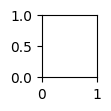

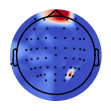

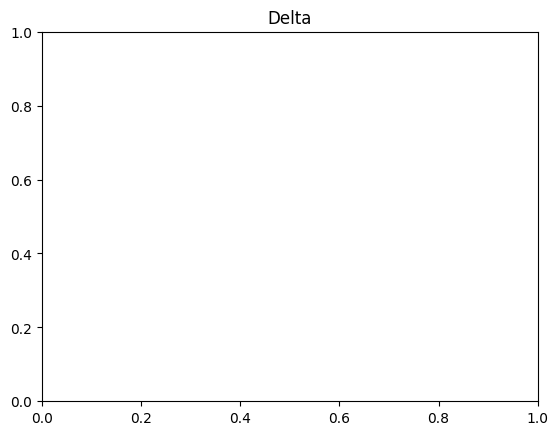

Plotting: Theta


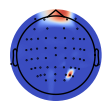

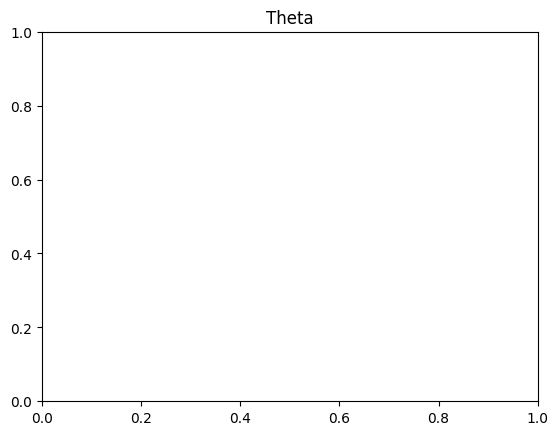

Plotting: Alpha


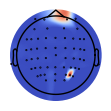

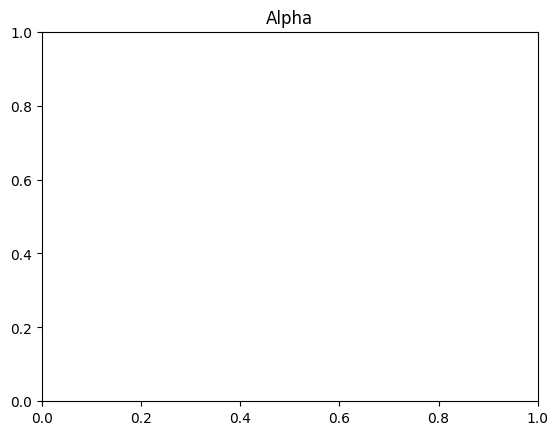

Plotting: Beta


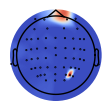

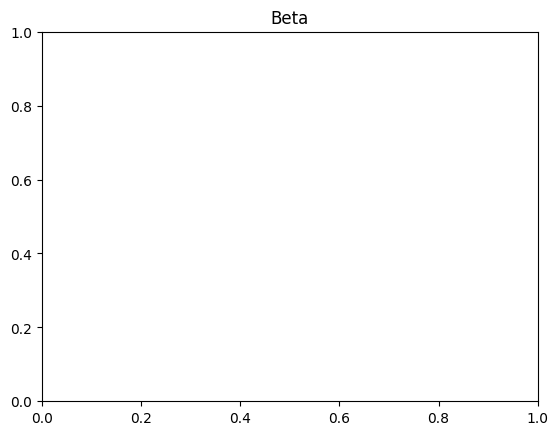

In [46]:
plot_topomaps(raw, psd, freqs)